<h1 align="center">CAMM Hackathon - Session 1</h1>
<p align="left"><em>26 September 2025</em></p>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KBForgeX/camm_hackathon/blob/k4my4r/docs/regressors/CAMM_Hackathon_1.ipynb)




**Data provenance** : The dataset aggregates measurements from a Dy–Er–Gd–Ho oxide wafer study in the CAMM by the Rack and Page groups


<h3>Goal: Feature → Target Prediction</h3>


This notebook hands you a **clean, standardized dataset** and a minimal prep pipeline so you can build your own predictive models. Your goal is to use the provided **features** (materials/structure descriptors) to **predict a target property** (default: *Thermal Conductivity*). The notebook **stops at data preparation**—you will implement and compare models (e.g., linear models, trees, neural nets) using the prepared data.

**What you’ll find here**
- A tidy table with `x`, `y` wafer coordinates and a set of engineered features (numeric, aligned to the same grid, with units harmonized).
- A simple example showing how to **select a target and features**, coerce to numeric, handle missing values (median imputation), and standardize inputs—ready for modeling.
- You can swap the target and feature lists to explore different prediction tasks.

**What you will do**
- Choose a **target** (e.g., `Thermal Conductivity`) and a subset of **features** you think are predictive.
- Train any models you like (sklearn, PyTorch, etc.) on the **prepared arrays**.
- Report basic metrics (RMSE, MAE, $R^2$) and, if useful, visualize predictions on the wafer grid using `x`, `y`.


#Data Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
# !gdown --fuzzy https://drive.google.com/file/d/1BSZ3YyTw6dqELnL9qpfV8V5wVrbA-BPz/view?usp=sharing

In [3]:
path = "/content/ReZrO_data.csv"   # update if path differs
df = pd.read_csv(path)

Let's see what all properties we have in the dataset

In [76]:
print("Dataframe shape:", df.shape)
display(df.head())

Dataframe shape: (2601, 17)


,x,y,Thermal Conductivity,Lattice Parameter(WPF),delta_d(SPF-WPF),d-spacing(WPF),Fluorite Size Disorder,Entropy,strain(LMFIT-dspacing),a111(LMFIT),a200(LMFIT),mismatch(LMFIT-lattice parameter),d111(LMFIT),d200(LMFIT),corr_length,fwhm111(LMFIT),delta_d/d
0,-2.5,-2.5,0.668247,5.245110,0.020399,2.622555,0.103832,3.924187,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
1,-2.5,-2.4,0.651635,5.245110,0.020399,2.622555,0.103727,3.927794,0.127131,5.245331,5.286782,-0.007902,3.028393,2.643391,2.94866,0.097076,0.007778
2,-2.5,-2.3,0.661063,5.244901,0.019877,2.622450,0.103588,3.939862,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
3,-2.5,-2.2,0.594712,5.244901,0.019877,2.622450,0.103447,3.951859,0.127240,5.245438,5.286226,-0.007776,3.028455,2.643113,2.94866,0.096367,0.007580
4,-2.5,-2.1,0.620809,5.244680,0.019664,2.622340,0.103338,3.955091,0.127249,5.245217,5.285954,-0.007766,3.028328,2.642977,2.94866,0.095942,0.007499


(2601, 17)

Let's plot them and see how they look

### Feature Definitions

1. **Lattice Parameter (WPF)**  
   Calculated by fitting the **whole XRD spectrum** using **TOPAS**.

2. **d-spacing (WPF)**  
   Average d-spacing calculated from fitting all peaks.

3. **Δd (SPF–WPF)**  
   Difference between *d-spacing (200 peak)* (2nd XRD peak) and *d-spacing (WPF)*:  
   $$ \Delta d = d_{WPF} - d_{\text{SPF}} $$

4. **delta_d/d**  
   Strain calculated from (2) and (3):  
   $$ \frac{\Delta d}{d} = \frac{d_{WPF} - d_{\text{SPF}}}{d_{\text{WPF}}} $$

5. **a111 (LMFit)**  
   Lattice parameter from fitting the **111 peak** (1st XRD peak) using the **LMFit** package.

6. **a200 (LMFit)**  
   Lattice parameter from fitting the **200 peak** (2nd XRD peak) using **LMFit**.

7. **Mismatch (LMFit – lattice parameter)**  
   $$ \text{Mismatch} = \frac{a_{111} - a_{200}}{a_{111}} $$

8. **d111 (LMFit)**  
   d-spacing of the 111 peak from LMFit.

9. **d200 (LMFit)**  
   d-spacing of the 200 peak from LMFit.

10. **Correlation Length**  
    Calculated from AFM images.

11. **FWHM111 (LMFit)**  
    Full Width at Half Maximum of the **111 peak**.

12. **Strain (LMFit – d-spacing)**  
    Strain calculated using LMFit d-spacing values:  
    $$ \frac{\Delta d}{d}{LMFIT} = \frac{d_{111} - d_{200}}{d_{111}} $$


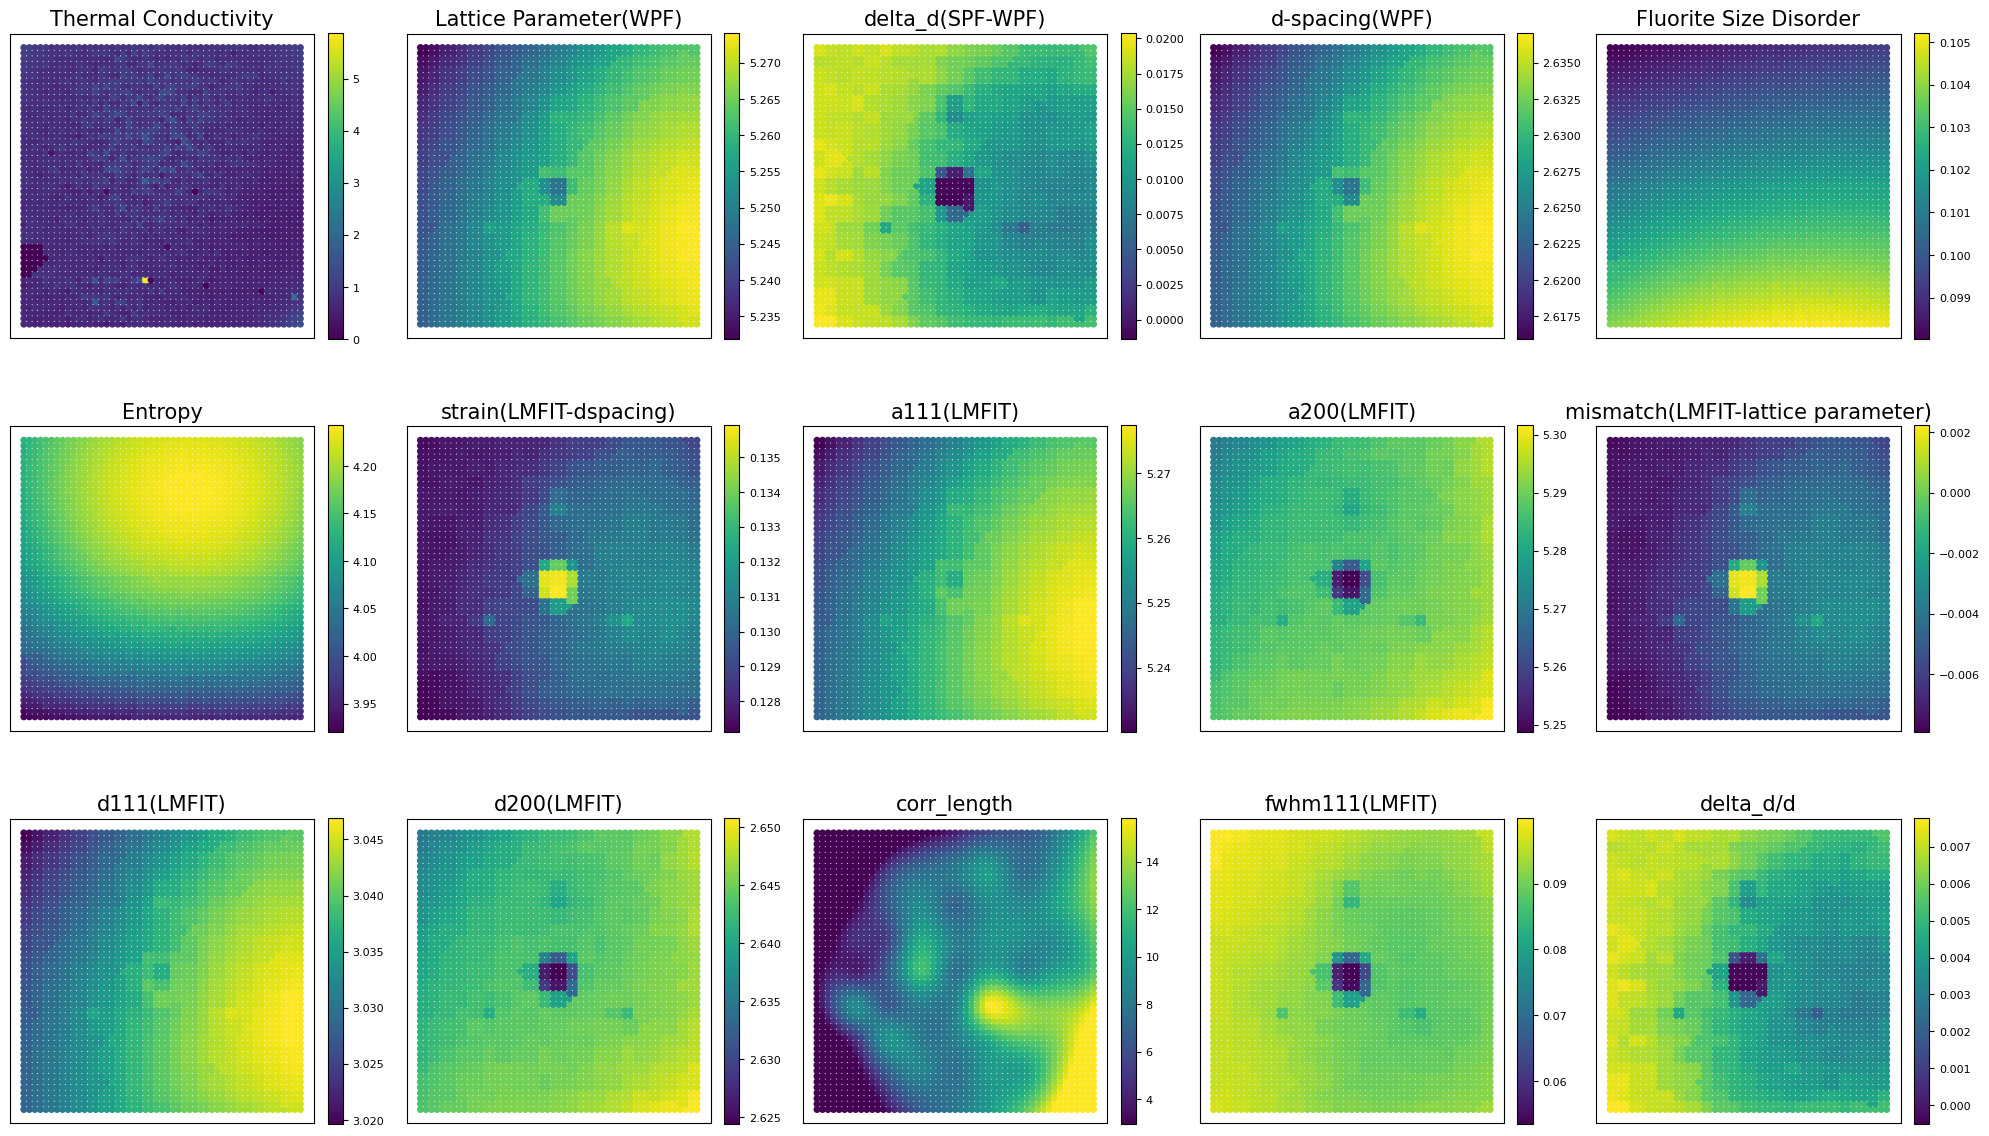

In [5]:
x = df["x"].to_numpy()
y = df["y"].to_numpy()

feature_cols = [c for c in df.columns if c not in ["x", "y"]]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    z = pd.to_numeric(df[col], errors="coerce").to_numpy()
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

    sc = ax.scatter(x[mask], y[mask], c=z[mask], s=16, cmap="viridis")
    ax.set_title(col, fontsize=15)
    ax.set_aspect("equal", "box")
    ax.set_xticks([]); ax.set_yticks([])

    # colorbar for each subplot
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplots
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# How to use this to train in networks?

In [72]:
features = [
    'a111(LMFIT)', 'mismatch(LMFIT-lattice parameter)',
    'Fluorite Size Disorder', 'Entropy',
    'corr_length',
]
target = 'Thermal Conductivity'

missing = [c for c in features + [target] if c not in df.columns]
if missing:
    raise KeyError(f"These columns are missing in df: {missing}")

In [73]:
for c in features + [target]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) drop rows with missing target
df_clean = df.dropna(subset=[target]).copy()

# 4) build matrices
X_raw = df_clean[features].to_numpy(dtype=np.float32) # Input features
y_raw = df_clean[target].to_numpy(dtype=np.float32)[:, None] #Target feature that needs to be predicted
XY    = df_clean[["x","y"]].to_numpy(dtype=np.float32) if set(["x","y"]).issubset(df_clean.columns) else None # can be used to plot predictions back on the grid


In [74]:
X_raw

array([[ 5.24533081e+00, -7.90200010e-03,  1.03831924e-01,
         3.92418694e+00,  2.94866037e+00],
       [ 5.24533081e+00, -7.90200010e-03,  1.03726678e-01,
         3.92779350e+00,  2.94866037e+00],
       [ 5.24543810e+00, -7.77600007e-03,  1.03587985e-01,
         3.93986201e+00,  2.94866037e+00],
       ...,
       [ 5.26651621e+00, -5.45400009e-03,  9.95715559e-02,
         4.18783092e+00,  1.27256212e+01],
       [ 5.26503801e+00, -5.76800015e-03,  9.94394571e-02,
         4.18475866e+00,  1.24681473e+01],
       [ 5.26503801e+00, -5.76800015e-03,  9.93696898e-02,
         4.18618298e+00,  1.21734533e+01]], dtype=float32)

In [75]:
X_train_raw, X_val_raw, y_train, y_val, XY_train, XY_val = train_test_split(
    X_raw, y_raw, XY, test_size=0.2, random_state=42
)


# Use this to split into training and testing dataset

In [9]:
X_train_raw

array([[ 5.23188210e+00, -7.44599989e-03,  9.82337371e-02,
         4.12553596e+00,  2.94866037e+00],
       [ 5.26637506e+00, -4.10499983e-03,  1.00447118e-01,
         4.23942614e+00,  9.13659668e+00],
       [ 5.24680424e+00, -6.78300019e-03,  9.90740880e-02,
         4.22030497e+00,  5.64193344e+00],
       ...,
       [ 5.26326323e+00, -5.24700014e-03,  1.03928693e-01,
         4.05287695e+00,  8.06601143e+00],
       [ 5.26700401e+00, -2.33300007e-03,  1.02605425e-01,
         4.15544415e+00,  8.43656349e+00],
       [ 5.24616814e+00, -6.74099987e-03,  9.92400646e-02,
         4.21648836e+00,  6.43144703e+00]], dtype=float32)

We split the dataset into training and test sets because we want to test our model on unseen data

## Build your network now

Make use of Chatgpt and build your own network to predict one of the features you select

## Linear Regresson

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)

# 3. transform validation features using the same scaler
X_val = scaler.transform(X_val_raw)

In [12]:
X_train

array([[-2.4739861 , -1.353125  , -1.9122685 , -0.13645753, -1.559633  ],
       [ 0.5728963 ,  0.6452248 , -0.7081532 ,  1.215064  ,  0.22122158],
       [-1.1558621 , -0.9565655 , -1.455104  ,  0.98815536, -0.7845236 ],
       ...,
       [ 0.29801685, -0.03783895,  1.1858797 , -0.9986937 , -0.08688708],
       [ 0.6284535 ,  1.7051097 ,  0.46600053,  0.2184594 ,  0.01975581],
       [-1.212051  , -0.9314439 , -1.36481   ,  0.9428641 , -0.5573059 ]],
      dtype=float32)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("r2 score:", r2_score(y_val, y_pred))
print("mean_sqare_error:", mean_squared_error(y_val, y_pred))

r2 score: 0.2163163423538208
mean_sqare_error: 0.02252291887998581


Cross validation

In [27]:
scores = cross_val_score(model, X_raw, y_raw.ravel(), cv=5, scoring='r2')

print("R² scores for each fold:", scores)
print("Mean R²:", np.mean(scores))
print("Std of R²:", np.std(scores))


print("-" *40)

y_cv_pred = cross_val_predict(model, X_raw, y_raw.ravel(), cv=5)
rmse = mean_squared_error(y_raw, y_cv_pred)
print("Cross-validated RMSE:", rmse)

R² scores for each fold: [-0.93815255 -0.04003108 -0.03979278  0.28841746 -0.32498777]
Mean R²: -0.2109093427658081
Std of R²: 0.4122387871958292
----------------------------------------
Cross-validated RMSE: 0.05089563503861427


R² score: How well the model’s predictions follow the real data

Negative R² scores mean the model is performing worse than predicting the mean of the target

On average, the model performs 21 % worse than the mean baseline.

This confirms the linear regression model is not explaining the variance in your target

This shows the variation in performance across folds.

A high standard deviation (0.41) →
the model’s performance is unstable and heavily depends on which samples it was trained/tested on.

RMSE (Root Mean Squared Error): On average, our predictions are off by about 0.0509 units of thermal conductivity.


If your target values range **0.5 – 0.7**, an error of 0.05 is about **7-10 %** of the range — fairly large.

If your target ranges **0 – 5**, then 0.05 is just **1%** of the range — quite small.

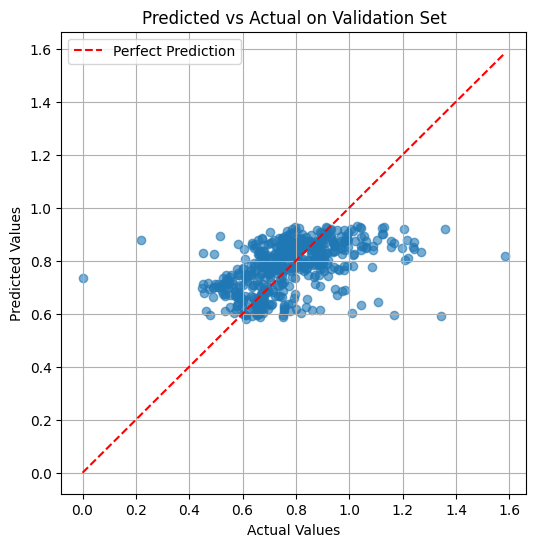

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--', label='Perfect Prediction')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual on Validation Set")
plt.legend()
plt.grid(True)
plt.show()

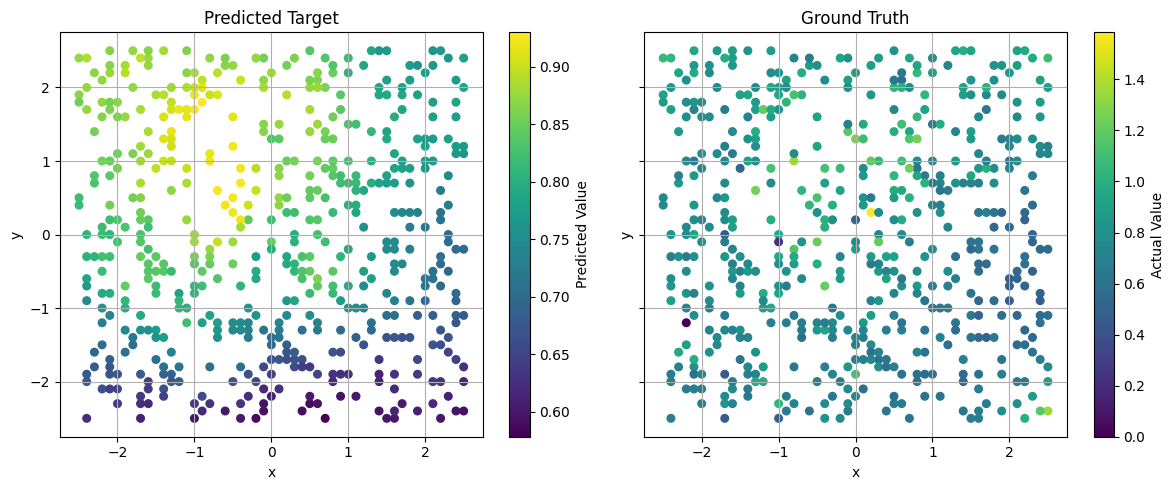

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# --- Plot 1: Predicted ---
sc1 = axes[0].scatter(
    XY_val[:, 0], XY_val[:, 1],
    c=y_pred, cmap='viridis', s=30
)
axes[0].set_title("Predicted Target")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(sc1, ax=axes[0], label="Predicted Value")

axes[0].grid(True)

# --- Plot 2: Ground Truth ---
sc2 = axes[1].scatter(
    XY_val[:, 0], XY_val[:, 1],
    c=y_val.ravel(), cmap='viridis', s=30
)
axes[1].set_title("Ground Truth")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(sc2, ax=axes[1], label="Actual Value")
axes[1].grid(True)


plt.tight_layout()

plt.show()


Lets try an stronger approach

## Random Forest

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [41]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],   # number of trees
    'max_depth': [3, 5, 7, 10, None]      # depth of each tree
}

In [42]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,            # 5-fold cross-validation
    n_jobs=-1,
    verbose=2        # shows progress
)

grid_search.fit(X_train, y_train.ravel())


Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='r2', verbose=2)

In [43]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R²:", grid_search.best_score_)

Best parameters: {'max_depth': 5, 'n_estimators': 200}
Best cross-validated R²: 0.3686597387463575


Train and test based on best params

In [46]:
rf_model = grid_search.best_estimator_
rf_model.fit(X_train, y_train.ravel())

y_val_pred = rf_model.predict(X_val)
print("Validation R²:", r2_score(y_val, y_val_pred))
print("Validation RMSE:", mean_squared_error(y_val, y_val_pred))


Validation R²: 0.3824811446363684
Validation RMSE: 0.01774737433952437


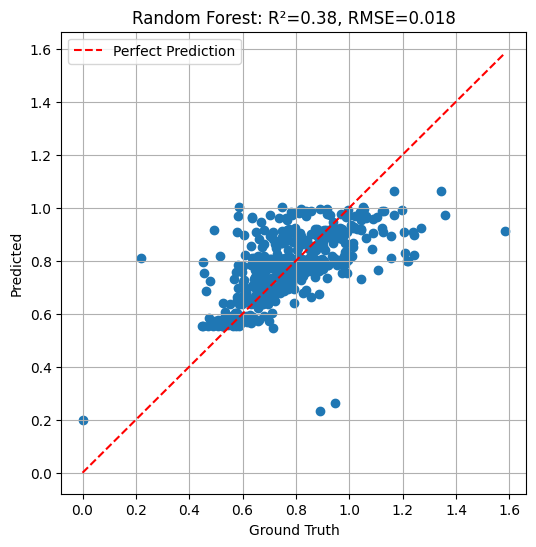

In [49]:
y_val_pred = rf_model.predict(X_val)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, )
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--', label='Perfect Prediction')

plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title(f"Random Forest: R²={r2_score(y_val, y_val_pred):.2f}, "
          f"RMSE={mean_squared_error(y_val, y_val_pred):.3f}")
plt.legend()
plt.grid(True)
plt.show()

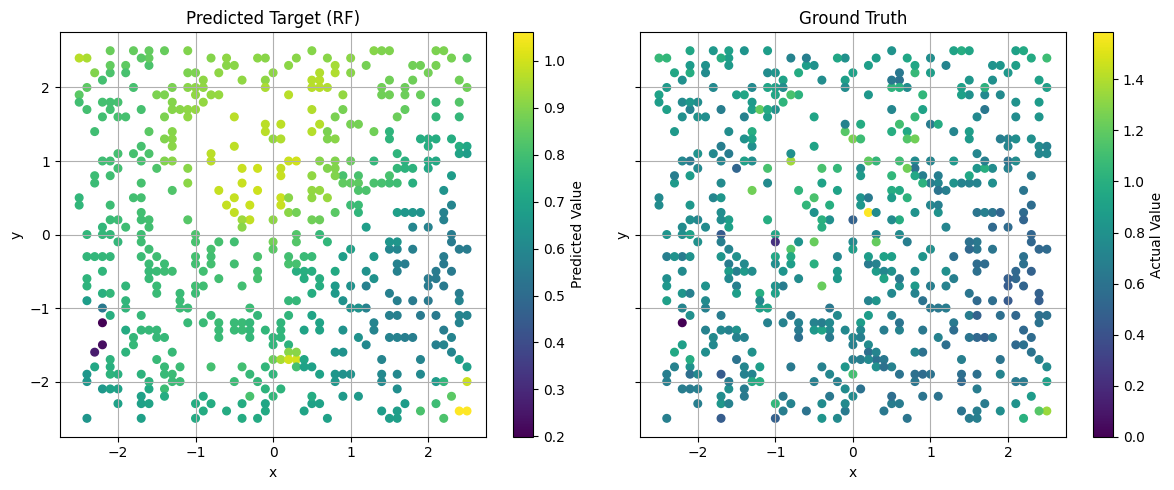

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# --- Plot 1: Predicted ---
sc1 = axes[0].scatter(
    XY_val[:, 0], XY_val[:, 1],
    c=y_val_pred, cmap='viridis', s=30
)
axes[0].set_title("Predicted Target (RF)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True)
fig.colorbar(sc1, ax=axes[0], label="Predicted Value")

# --- Plot 2: Ground Truth ---
sc2 = axes[1].scatter(
    XY_val[:, 0], XY_val[:, 1],
    c=y_val.ravel(), cmap='viridis', s=30
)
axes[1].set_title("Ground Truth")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].grid(True)
fig.colorbar(sc2, ax=axes[1], label="Actual Value")

plt.tight_layout()
plt.show()


Benchmarking

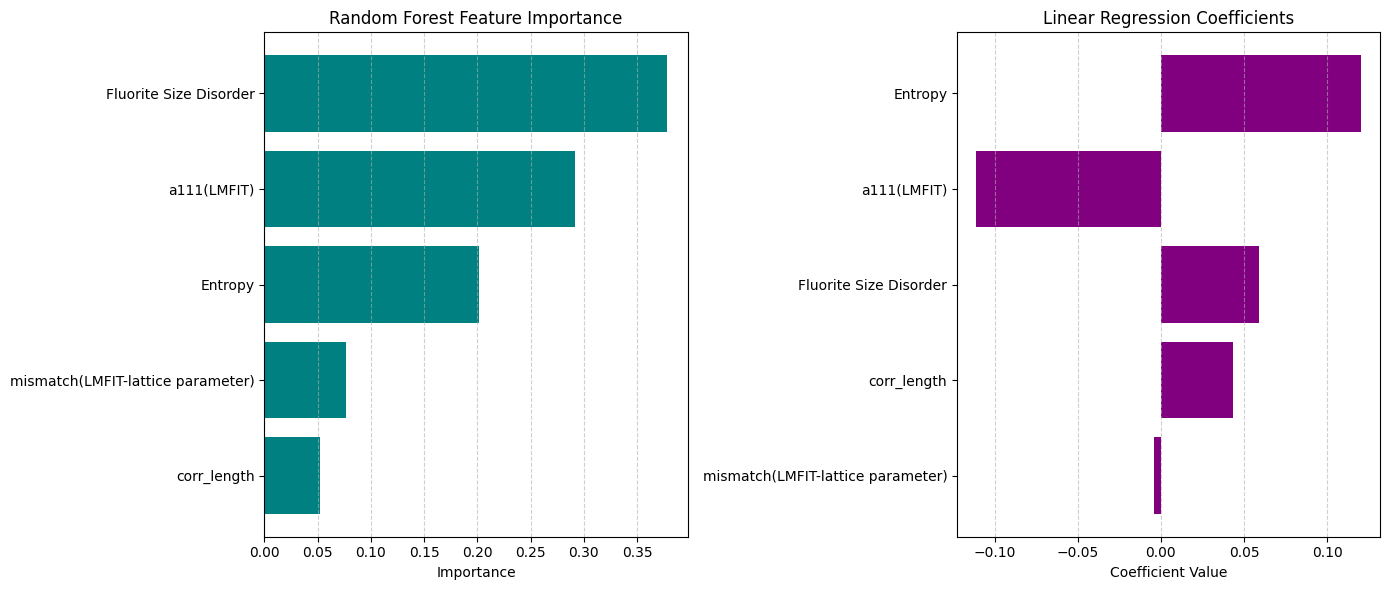

In [71]:
# --- Random Forest ---
rf_importances = rf_model.feature_importances_
feature_names = np.array(features)
rf_idx = np.argsort(rf_importances)[::-1]  # sort descending by importance

# --- Linear Regression ---
lin_coefs = model.coef_.ravel()
lin_idx = np.argsort(np.abs(lin_coefs))[::-1]  # sort by absolute coefficient magnitude

# --- Create side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Random Forest Plot ---
axes[0].barh(feature_names[rf_idx], rf_importances[rf_idx], color='teal')
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Importance")
axes[0].invert_yaxis()   # largest at the top
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# --- Linear Regression Plot ---
axes[1].barh(feature_names[lin_idx], lin_coefs[lin_idx], color='purple')
axes[1].set_title("Linear Regression Coefficients")
axes[1].set_xlabel("Coefficient Value")
axes[1].invert_yaxis()   # largest at the top
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

# Layout
plt.tight_layout()
plt.show()


Positive coefficient → as the feature’s value increases, the predicted target also increases.

Negative coefficient → as the feature’s value increases, the predicted target decreases.